In [1]:
!pip install scipy statsmodels scikit-learn plotly

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import *

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Statistical Analysis

In [5]:
df=pd.read_csv("cleaned_global_ecommerce_sales.csv")

df.head()

,order_id,order_date,customer_name,customer_segment,country,region,product_category,product_name,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit,payment_method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11746,2023-01-05,Fatima Suzuki,Consumer,Mexico,North America,Furniture,Bookshelf 5-Tier,1,61.93,10,55.74,5.88,12.70,PayPal


In [7]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1810 entries, 0 to 1809
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1810 non-null   object 
 1   order_date        1810 non-null   object 
 2   customer_name     1810 non-null   object 
 3   customer_segment  1810 non-null   object 
 4   country           1810 non-null   object 
 5   region            1810 non-null   object 
 6   product_category  1810 non-null   object 
 7   product_name      1810 non-null   object 
 8   quantity          1810 non-null   int64  
 9   unit_price        1810 non-null   float64
 10  discount_percent  1810 non-null   int64  
 11  total_sales       1810 non-null   float64
 12  shipping_cost     1810 non-null   float64
 13  profit            1810 non-null   float64
 14  payment_method    1810 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 212.2+ KB


,0
order_id,0
order_date,0
customer_name,0
customer_segment,0
country,0
region,0
product_category,0
product_name,0
quantity,0
unit_price,0


In [9]:
df["total_sales"].mean()

np.float64(144.3562320441989)

In [10]:
df["total_sales"].median()

96.62

In [11]:
df["total_sales"].mode()

,total_sales
0,7.02
1,8.96
2,10.50
3,12.35
4,12.64
...,...
67,154.20
68,164.85
69,198.40
70,308.80


In [12]:
df["total_sales"].var()

19996.58639983559

In [13]:
df["total_sales"].std()

141.40928682316303

In [14]:
df["total_sales"].skew()

np.float64(1.389599036912595)

In [15]:
df["total_sales"].kurt()

np.float64(1.2461656277163211)

In [16]:
from scipy.stats import t

mean=df["total_sales"].mean()

std=df["total_sales"].std()

n=len(df)

ci=t.interval(0.95,n-1,loc=mean,scale=std/np.sqrt(n))

print(ci)

(np.float64(137.83728569251625), np.float64(150.87517839588153))


In [17]:
stats.ttest_1samp(df["total_sales"],500)

TtestResult(statistic=np.float64(-106.99822132639665), pvalue=np.float64(0.0), df=np.int64(1809))

In [19]:
table=pd.crosstab(df["product_category"],df["region"])

stats.chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(13.289235672612943), pvalue=np.float64(0.34837304746306286), dof=12, expected_freq=array([[103.8281768 ,  98.97845304,  42.10441989, 115.95248619,
         38.13646409],
       [ 98.10331492,  93.52099448,  39.78287293, 109.55911602,
         36.03370166],
       [133.49337017, 127.25801105,  54.13425414, 149.08176796,
         49.03259669],
       [135.57513812, 129.24254144,  54.97845304, 151.40662983,
         49.79723757]]))

In [20]:
stats.f_oneway(

df[df["product_category"]=="Furniture"]["total_sales"],

df[df["product_category"]=="Technology"]["total_sales"],

df[df["product_category"]=="Office Supplies"]["total_sales"]

)

F_onewayResult(statistic=np.float64(343.9122584615333), pvalue=np.float64(2.4121695062271715e-122))

In [21]:
df.corr(numeric_only=True)

,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit
quantity,1.000000,-0.208241,0.012233,0.442940,0.740684,0.431358
unit_price,-0.208241,1.000000,0.048363,0.604609,-0.144620,0.547834
discount_percent,0.012233,0.048363,1.000000,-0.047870,0.012435,-0.189241
total_sales,0.442940,0.604609,-0.047870,1.000000,0.324894,0.967071
shipping_cost,0.740684,-0.144620,0.012435,0.324894,1.000000,0.277673
profit,0.431358,0.547834,-0.189241,0.967071,0.277673,1.000000


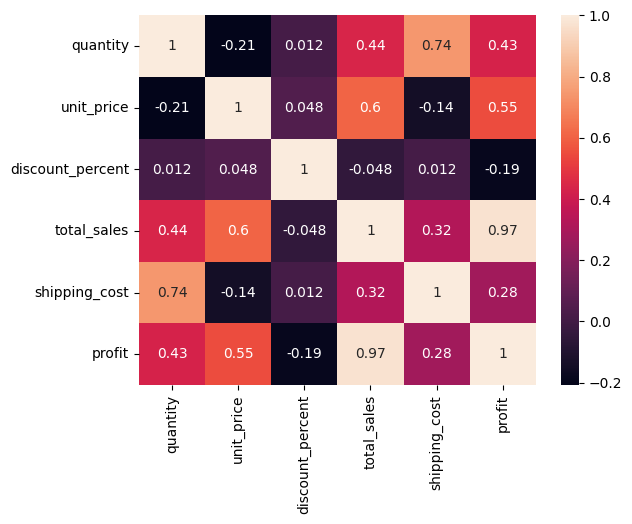

In [22]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

plt.show()

# Time Series Analysis

In [25]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [28]:
df=df.set_index("order_date")

/tmp/ipykernel_1563/3823524477.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly=df["total_sales"].resample("M").sum()


<Axes: xlabel='order_date'>

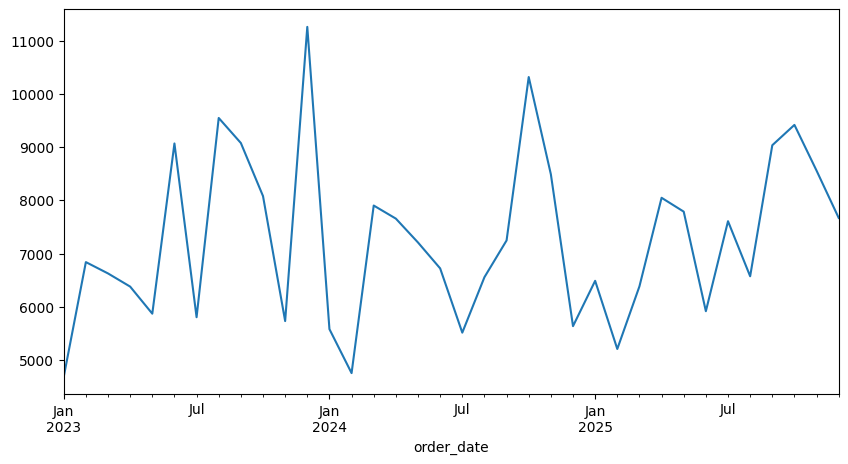

In [29]:
monthly=df["total_sales"].resample("M").sum()

monthly.plot(figsize=(10,5))

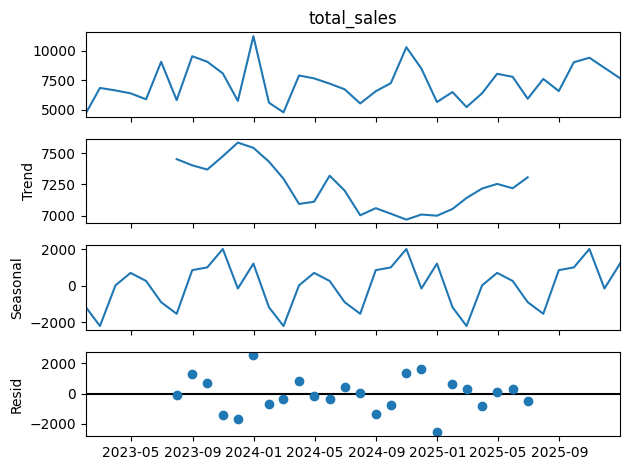

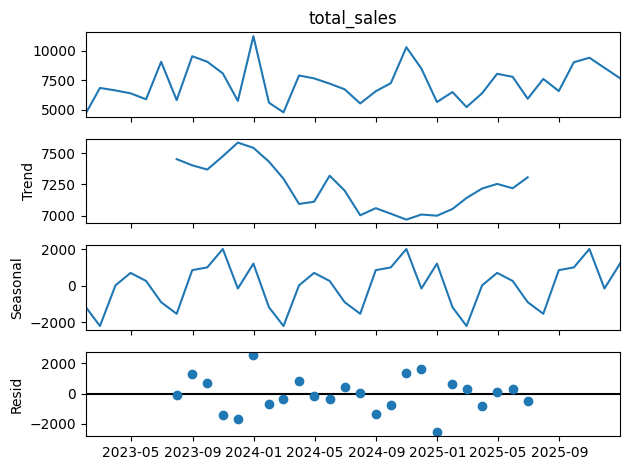

In [30]:
result=seasonal_decompose(monthly)

result.plot()

In [31]:
adf=adfuller(monthly.dropna())

print(adf)

(np.float64(-5.846156171594162), np.float64(3.679533919866727e-07), 0, 35, {'1%': np.float64(-3.6327426647230316), '5%': np.float64(-2.9485102040816327), '10%': np.float64(-2.6130173469387756)}, np.float64(442.68345836634))


<Axes: xlabel='order_date'>

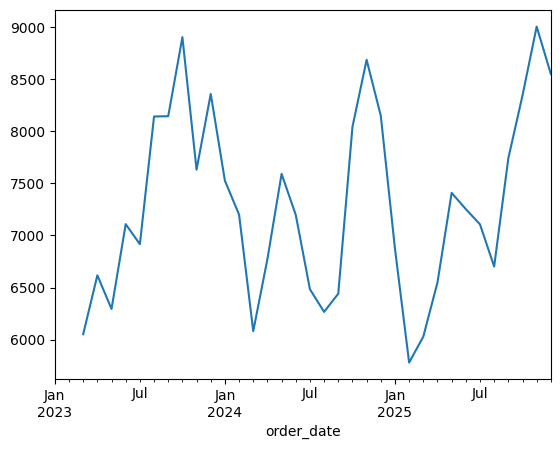

In [32]:
monthly.rolling(3).mean().plot()

<Axes: >

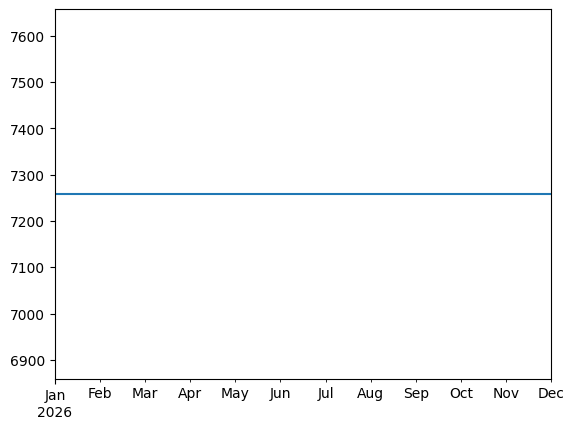

In [33]:
model=ExponentialSmoothing(monthly)

fit=model.fit()

forecast=fit.forecast(12)

forecast.plot()

In [34]:
model=ARIMA(monthly,order=(1,1,1))

model=model.fit()

forecast=model.forecast(12)

forecast

,predicted_mean
2026-01-31,7633.465069
2026-02-28,7626.296521
2026-03-31,7624.881453
2026-04-30,7624.602120
2026-05-31,7624.546980
2026-06-30,7624.536095
2026-07-31,7624.533946
2026-08-31,7624.533522
2026-09-30,7624.533438
2026-10-31,7624.533422


In [35]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(monthly[-12:],forecast[:12])

print(mae)

1028.0494841912973


In [36]:
rmse=np.sqrt(mean_squared_error(monthly[-12:],forecast[:12]))

print(rmse)

1257.2136809905862


# Customer Segmentation

In [39]:
X=df[["total_sales","quantity","profit"]]

In [40]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

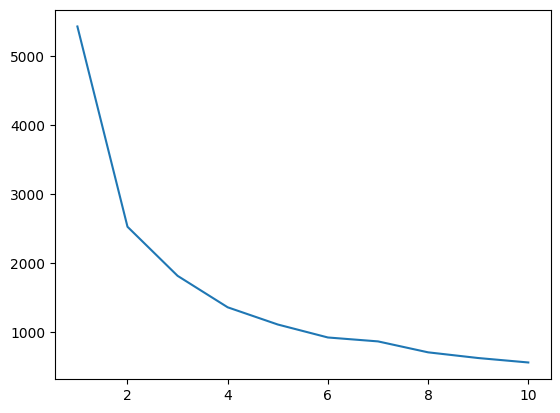

In [41]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)

In [42]:
kmeans=KMeans(n_clusters=5)

cluster=kmeans.fit_predict(X)

df["Cluster"]=cluster

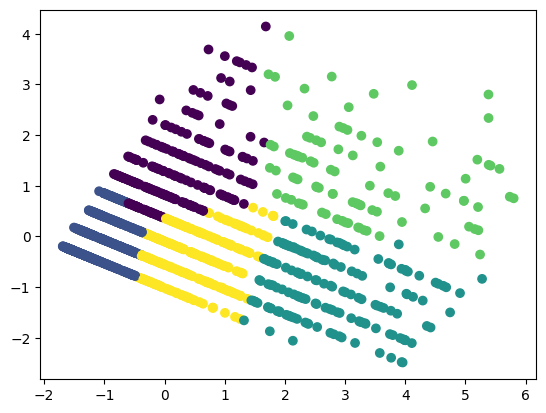

In [43]:
pca=PCA(n_components=2)

pca_data=pca.fit_transform(X)

plt.scatter(pca_data[:,0],pca_data[:,1],c=cluster)

In [44]:
df.groupby("Cluster").mean(numeric_only=True)

,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit
Cluster,,,,,,
0,6.019231,20.089769,9.461538,102.802038,16.324538,29.043538
1,1.782212,35.510011,8.973774,47.063991,10.365929,8.851277
2,3.903409,140.074943,6.051136,434.393068,13.362330,155.909432
3,9.354167,48.376458,9.114583,391.130938,21.110521,134.715521
4,2.760599,101.161247,8.478803,197.704190,11.789601,64.042943


# Predictive Modeling

In [45]:
X=df[["quantity","profit"]]

y=df["total_sales"]

In [46]:
X_train,X_test,y_train,y_test=train_test_split(

X,y,test_size=0.2,random_state=42

)

In [47]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [48]:
pred=model.predict(X_test)

In [49]:
print(r2_score(y_test,pred))

print(mean_absolute_error(y_test,pred))

print(np.sqrt(mean_squared_error(y_test,pred)))

0.9254702278301478
22.496909830086796
37.53186021363724


In [55]:
from sklearn.tree import DecisionTreeRegressor

model=DecisionTreeRegressor()

model.fit(X_train,y_train)

pred=model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [56]:
print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.8798270993117566
MAE: 28.575082872928178
RMSE: 47.658291072323564


In [57]:
importance=model.feature_importances_

print(importance)

[0.01793998 0.98206002]
